MicroGPT appliqué à la génération de molécules

Ici une base de données de 10 000 molécules d'entraînement est utilisé pour tenter de générer 50 molécules à l'aide d'un modèle préalablement entraîné sur 6000 étapes. 
NB: Pensez à modifier les chemins d'accès si vous souhaitez utiliser l'algorithme

In [21]:
# ── Cellule 1 : installation ──────────────────────────────────────────────

!pip install pandas rdkit matplotlib openpyxl xlsxwriter --quiet

In [22]:
# ── Cellule 2 : imports ───────────────────────────────────────────────────
import ast, math, random
import pandas as pd
from rdkit import Chem
import time
random.seed(42)

In [23]:
# ── Cellule 3 : chargement des tokens pré-calculés ────────────────────────
t_init=time.time()
df = pd.read_excel(r"C:\users\alexi\Downloads\10000SMILES_df.xlsx")  #Adapter le chemin si besoin

# smiles2Tokens est stockée comme string "['C','C','(',...]"
# ast.literal_eval la convertit en vraie liste Python
docs = [ast.literal_eval(row) for row in df['smiles2Tokens']]




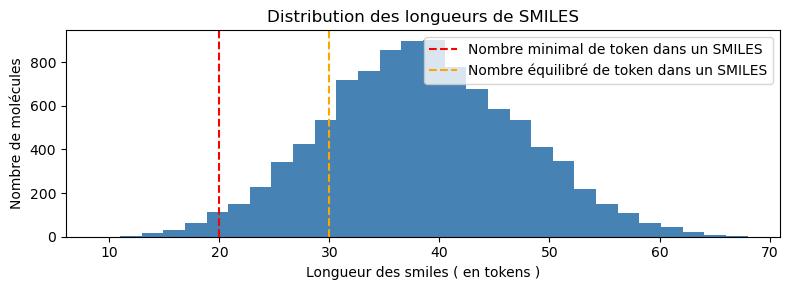

max=15 : 33 molécules conservées (0% du dataset de base)
max=20 : 231 molécules conservées (2% du dataset de base)
max=25 : 777 molécules conservées (8% du dataset de base)
max=30 : 1914 molécules conservées (19% du dataset de base)
max=40 : 6043 molécules conservées (60% du dataset de base)


In [24]:
# ── Cellule 3b : Distribution des longueurs de SMILES et limitation de la longeur maximale des SMILES ────────────────────────
""" On regarde la distribution des smiles
Pour essayer de fixer une taille maximale à ne pas dépasser
Pour notre smiles
 Objectif: réduire considérablement le temps de calcul sans
Trop impacter notre validité"""

import matplotlib.pyplot as plt

longueurs = [len(doc) for doc in docs]
plt.figure(figsize=(8,3))
plt.hist(longueurs, bins=30, color='steelblue')
plt.axvline(x=20, color='red', linestyle='--', label='Nombre minimal de token dans un SMILES')
plt.axvline(x=30, color='orange', linestyle='--', label='Nombre équilibré de token dans un SMILES')
plt.xlabel('Longueur des smiles ( en tokens )')
plt.ylabel('Nombre de molécules')
plt.title('Distribution des longueurs de SMILES')
plt.legend()
plt.tight_layout()
plt.show()

for seuil in [15, 20, 25, 30, 40]:
    n = sum(1 for l in longueurs if l <= seuil)
    print(f"max={seuil} : {n} molécules conservées ({100*n/len(longueurs):.0f}% du dataset de base)")

taille_max=26
docs = [smiles for smiles in docs if len(smiles) <= taille_max]
random.shuffle(docs)


In [25]:
# ── Cellule 3c : Initialisation du vocabulaire ────────────────────────
all_token_types = sorted(set(t for doc in docs for t in doc))
BOS_ID    = len(all_token_types)   # entier spécial hors vocab chimique
vocab_size = len(all_token_types) + 1
tok2id = {t: i for i, t in enumerate(all_token_types)}
id2tok = {i: t for i, t in enumerate(all_token_types)}
id2tok[BOS_ID] = '<BOS>'

def encode(doc_tokens):
    """list[str] → list[int], encadré par BOS_ID."""
    return [BOS_ID] + [tok2id[t] for t in doc_tokens] + [BOS_ID]

def decode(ids):
    """list[int] → SMILES str (BOS exclus)."""
    return ''.join(id2tok[i] for i in ids if i != BOS_ID)

longest    = max(len(d) for d in docs)
print(f'Molécules chargées : {len(docs):,}')
print(f'Vocabulaire        : {vocab_size} tokens')
print(f'Tokens             : {all_token_types}')
print(f'Séquence max       : {longest} tokens')
print()
print('Exemples :')
for doc in docs[:3]:
    print(f'  {decode(encode(doc))[:60]}  →  {doc[:8]}…')

Molécules chargées : 953
Vocabulaire        : 42 tokens
Tokens             : ['#', '(', ')', '-', '/', '1', '2', '3', '4', '=', 'Br', 'C', 'Cl', 'F', 'I', 'N', 'O', 'P', 'S', '[C@@H]', '[C@@]', '[C@H]', '[C@]', '[N+]', '[N-]', '[NH+]', '[NH2+]', '[NH3+]', '[O-]', '[P@]', '[S-]', '[S@@]', '[n+]', '[n-]', '[nH+]', '[nH]', '\\', 'c', 'n', 'o', 's']
Séquence max       : 26 tokens

Exemples :
  N#Cc1nc(CCl)c[n+]([O-])c1N  →  ['N', '#', 'C', 'c', '1', 'n', 'c', '(']…
  CNc1nnc(-c2ccccc2Cl)s1  →  ['C', 'N', 'c', '1', 'n', 'n', 'c', '(']…
  CO[C@@]12C=C[C@@H](CC1)CC2=O  →  ['C', 'O', '[C@@]', '1', '2', 'C', '=', 'C']…


In [26]:
# ── Cellule 4 : autograd (identique à microgpt.py de Karpathy) ───────────
class Value:
    __slots__ = ('data', 'grad', '_children', '_local_grads')
    def __init__(self, data, children=(), local_grads=()):
        self.data = data
        self.grad = 0
        self._children = children
        self._local_grads = local_grads
    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        return Value(self.data + other.data, (self, other), (1, 1))
    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        return Value(self.data * other.data, (self, other), (other.data, self.data))
    def __pow__(self, other): return Value(self.data**other, (self,), (other * self.data**(other-1),))
    def log(self):  return Value(math.log(self.data),  (self,), (1/self.data,))
    def exp(self):  return Value(math.exp(self.data),  (self,), (math.exp(self.data),))
    def relu(self): return Value(max(0, self.data),    (self,), (float(self.data > 0),))
    def __neg__(self):          return self * -1
    def __radd__(self, other):  return self + other
    def __sub__(self, other):   return self + (-other)
    def __rsub__(self, other):  return other + (-self)
    def __rmul__(self, other):  return self * other
    def __truediv__(self, other):  return self * other**-1
    def __rtruediv__(self, other): return other * self**-1
    def backward(self):
        topo, visited = [], set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._children: build_topo(child)
                topo.append(v)
        build_topo(self)
        self.grad = 1
        for v in reversed(topo):
            for child, lg in zip(v._children, v._local_grads):
                child.grad += lg * v.grad

In [27]:
# ── Cellule 5 : hyperparamètres ───────────────────────────────────────────


n_layer    = 1
n_embd     = 16
block_size = longest + 2      
n_head     = 4
head_dim   = n_embd // n_head

assert n_embd % n_head == 0

matrix = lambda nout, nin, std=0.08: [
    [Value(random.gauss(0, std)) for _ in range(nin)] for _ in range(nout)
]
state_dict = {
    'wte':     matrix(vocab_size, n_embd),
    'wpe':     matrix(block_size, n_embd),
    'lm_head': matrix(vocab_size, n_embd),
}
for i in range(n_layer):
    state_dict[f'layer{i}.attn_wq'] = matrix(n_embd, n_embd)
    state_dict[f'layer{i}.attn_wk'] = matrix(n_embd, n_embd)
    state_dict[f'layer{i}.attn_wv'] = matrix(n_embd, n_embd)
    state_dict[f'layer{i}.attn_wo'] = matrix(n_embd, n_embd)
    state_dict[f'layer{i}.mlp_fc1'] = matrix(4 * n_embd, n_embd)
    state_dict[f'layer{i}.mlp_fc2'] = matrix(n_embd, 4 * n_embd)

params = [p for mat in state_dict.values() for row in mat for p in row]
print(f'Paramètres  : {len(params):,}')
print(f'block_size  : {block_size}')
print(f'vocab_size  : {vocab_size}')

Paramètres  : 4,864
block_size  : 28
vocab_size  : 42


In [28]:
# ── Cellule 6 : architecture GPT (identique à microgpt.py) ───────────────
def linear(x, w):
    return [sum(wi * xi for wi, xi in zip(wo, x)) for wo in w]

def softmax(logits):
    max_val = max(val.data for val in logits)
    exps = [(val - max_val).exp() for val in logits]
    total = sum(exps)
    return [e / total for e in exps]

def rmsnorm(x):
    ms = sum(xi * xi for xi in x) / len(x)
    return [xi * (ms + 1e-5) ** -0.5 for xi in x]

def gpt(token_id, pos_id, keys, values):
    x = [t + p for t, p in zip(state_dict['wte'][token_id],
                                state_dict['wpe'][pos_id])]
    x = rmsnorm(x)
    for li in range(n_layer):
        x_res = x
        x = rmsnorm(x)
        q = linear(x, state_dict[f'layer{li}.attn_wq'])
        k = linear(x, state_dict[f'layer{li}.attn_wk'])
        v = linear(x, state_dict[f'layer{li}.attn_wv'])
        keys[li].append(k); values[li].append(v)
        x_attn = []
        for h in range(n_head):
            hs  = h * head_dim
            q_h = q[hs:hs+head_dim]
            k_h = [ki[hs:hs+head_dim] for ki in keys[li]]
            v_h = [vi[hs:hs+head_dim] for vi in values[li]]
            al  = [sum(q_h[j]*k_h[t][j] for j in range(head_dim))/head_dim**0.5
                   for t in range(len(k_h))]
            aw  = softmax(al)
            x_attn.extend([sum(aw[t]*v_h[t][j] for t in range(len(v_h)))
                           for j in range(head_dim)])
        x = linear(x_attn, state_dict[f'layer{li}.attn_wo'])
        x = [a + b for a, b in zip(x, x_res)]
        x_res = x
        x = rmsnorm(x)
        x = linear(x, state_dict[f'layer{li}.mlp_fc1'])
        x = [xi.relu() for xi in x]
        x = linear(x, state_dict[f'layer{li}.mlp_fc2'])
        x = [a + b for a, b in zip(x, x_res)]
    return linear(x, state_dict['lm_head'])

In [29]:
# — Cellule 6b : chargement checkpoint  —
import pickle
import os

reponse = input("Souhaitez vous importer un point de sauvegarde [y]/[n] ?")

if reponse == 'y':
    print("Entre le chemin complet vers ton fichier .pkl :")
    print("Exemple : C:/Users/toi/Documents/checkpoint.pkl")
    filename = input("Chemin : ").strip().strip('"')  # strip() enlève les espaces, strip('"') gère le copier-coller Windows

    if not os.path.exists(filename):
        print(f"Fichier introuvable : {filename}")
        print("Démarrage depuis zéro.")
        loss_history = []
        time_history = []
    else:
        with open(filename, 'rb') as f:
            checkpoint = pickle.load(f)
        for p, saved_data in zip(params, checkpoint['params_data']):
            p.data = saved_data
        if 'loss_history' in checkpoint:
            loss_history = checkpoint['loss_history']
            time_history = checkpoint['time_history']
            print(f"  Historique : {len(loss_history)} steps récupérés")
        else:
            loss_history = []
            time_history = []
            print("  Pas d'historique dans ce checkpoint")
        print(f"  Poids restaurés")
        print(f"  Step repris : {checkpoint['step']}")
        print(f"  Loss        : {checkpoint['loss']:.4f}")

else:
    loss_history = []
    time_history = []
    print("Démarrage depuis zéro")

Entre le chemin complet vers ton fichier .pkl :
Exemple : C:/Users/toi/Documents/checkpoint.pkl
  Historique : 6000 steps récupérés
  Poids restaurés
  Step repris : 6000
  Loss        : 0.8898


In [30]:
# — Cellule 7 : entraînement avec sauvegarde + historique cumulé —
import time, pickle
import os

# Dossier local où sauvegarder les checkpoints
CHECKPOINT_DIR = r"C:\Users\alexi\Downloads\Checkpoint 10 000" # modifier le chemin si besoin
os.makedirs(CHECKPOINT_DIR, exist_ok=True)  # Crée le dossier s'il n'existe pas

# — Conserve l'historique des runs précédents —
if 'loss_history' not in dir():
    loss_history = []
if 'time_history' not in dir():
    time_history = []

learning_rate, beta1, beta2, eps_adam = 0.005, 0.85, 0.99, 1e-8
m_buf = [0.0] * len(params)
v_buf = [0.0] * len(params)

num_steps  = 0
batch_size = 8

for step in range(num_steps):
    t0 = time.time()

    batch = random.sample(docs, batch_size)
    batch_losses = []

    for doc in batch:
        tokens = encode(doc)
        n      = min(block_size, len(tokens) - 1)

        keys_buf   = [[] for _ in range(n_layer)]
        vals_buf   = [[] for _ in range(n_layer)]
        step_losses = []

        for pos_id in range(n):
            logits = gpt(tokens[pos_id], pos_id, keys_buf, vals_buf)
            probs  = softmax(logits)
            step_losses.append(-probs[tokens[pos_id + 1]].log())

        batch_losses.append((1/n) * sum(step_losses))

    loss = sum(batch_losses) / batch_size
    loss.backward()

    lr_t = learning_rate * (1 - step / num_steps)
    for i, p in enumerate(params):
        m_buf[i] = beta1 * m_buf[i] + (1 - beta1) * p.grad
        v_buf[i] = beta2 * v_buf[i] + (1 - beta2) * p.grad**2
        m_hat    = m_buf[i] / (1 - beta1**(step+1))
        v_hat    = v_buf[i] / (1 - beta2**(step+1))
        p.data  -= lr_t * m_hat / (v_hat**0.5 + eps_adam)
        p.grad   = 0

    elapsed = time.time() - t0
    loss_history.append(loss.data)
    time_history.append(elapsed)

    if (step+1) % 10 == 0:
        total_steps = len(loss_history)
        print(f'step {total_steps:5d} | loss {loss.data:.4f} | {elapsed:.1f}s')

    # — Sauvegarde locale toutes les 100 steps —
    if (step+1) % 100 == 0:
        checkpoint = {
            'params_data' : [p.data for p in params],
            'step'        : len(loss_history),
            'loss'        : loss.data,
            'loss_history': loss_history,
            'time_history': time_history
        }
        save_path = os.path.join(CHECKPOINT_DIR, f'checkpoint_{len(loss_history)}.pkl')
        with open(save_path, 'wb') as f:
            pickle.dump(checkpoint, f)
        print(f'Checkpoint {len(loss_history)} sauvegardé → {save_path}')

print(f'\nTerminé. Loss finale : {loss_history[-1]:.4f}')
print(f'Temps moyen/step    : {sum(time_history)/len(time_history):.2f}s')
print(f'Temps total         : {sum(time_history)/60:.1f} min')


Terminé. Loss finale : 0.8898
Temps moyen/step    : 11.83s
Temps total         : 1182.8 min


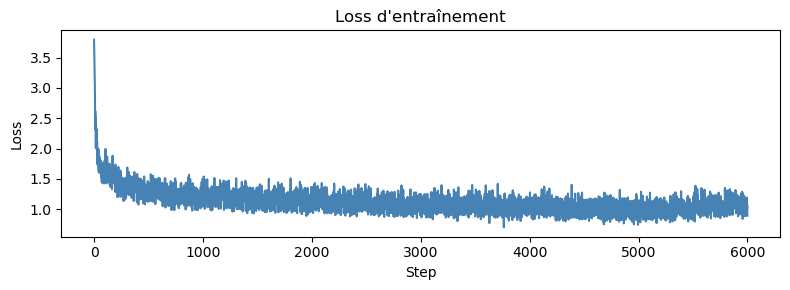


Terminé. Loss finale : 0.8898
loss min à l étape3762
0.6986830212128563
6000


In [31]:
# ── Cellule 7b : courbe de loss ────────────────────────────────────────────
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 3))
plt.plot(loss_history, linewidth=1.5, color='steelblue')
plt.xlabel('Step'); plt.ylabel('Loss')
plt.title("Loss d'entraînement")
plt.tight_layout(); plt.show()
print(f'\nTerminé. Loss finale : {loss_history[-1]:.4f}')
loss_min_steps= loss_history.index(min(loss_history))-1
print(f'loss min à l étape{loss_min_steps}')
loss_min=min(loss_history)
print(loss_min)
print(f'{len(loss_history)}')


In [32]:
# ── Cellule 8 : inférence + validation RDKit ─────────────────────────────
temperature = 0.5   # [0.5 = conservateur, 1.0 = créatif]
top_k       = 7    # on ne garde que les 10 tokens les plus probables
n_samples   = 50

print(f'Génération de {n_samples} molécules (température={temperature}, top_k={top_k})\n')
valid = []

for idx in range(n_samples):
    keys_buf = [[] for _ in range(n_layer)]
    vals_buf = [[] for _ in range(n_layer)]
    token_id = BOS_ID
    out_ids  = []

    for pos_id in range(block_size):
        logits = gpt(token_id, pos_id, keys_buf, vals_buf)

        # ── Étape 1 : appliquer la temperature sur les logits bruts ──────
        scaled_logits = [l / temperature for l in logits]

        # ── Étape 2 : top_k — on ne garde que les K meilleurs logits ─────
        top_k_indices = sorted(
            range(vocab_size),
            key=lambda i: scaled_logits[i].data,
            reverse=True
        )[:top_k]


        filtered_logits = [
            scaled_logits[i] if i in top_k_indices
            else Value(-1e9)   # équivalent de -inf pour notre Value
            for i in range(vocab_size)
        ]

        # ── Étape 3 : softmax sur les logits filtrés ─────────────────────
        probs = softmax(filtered_logits)

        # ── Étape 4 : échantillonnage parmi les tokens restants ───────────
        token_id = random.choices(
            range(vocab_size),
            weights=[p.data for p in probs]
        )[0]

        if token_id == BOS_ID:
            break
        out_ids.append(token_id)

    smi = decode(out_ids)
    mol = Chem.MolFromSmiles(smi)
    ok  = mol is not None
    if ok:
        valid.append(smi)
    print(f'  {"✓" if ok else "✗"}  {smi}')

print(f'\nValidité : {len(valid)}/{n_samples} ({100*len(valid)/n_samples:.0f}%)')
print('(Viser >50% après convergence = le modèle a appris la grammaire SMILES)')


train_smiles_canonical = set()
for doc in docs:
    smi = decode(encode(doc))
    mol = Chem.MolFromSmiles(smi)
    if mol:
        train_smiles_canonical.add(Chem.MolToSmiles(mol))  # forme canonique

print(f"Base d'entraînement : {len(train_smiles_canonical)} SMILES canoniques")

# Vérifier chaque molécule générée
nouveaux    = []
doublons    = []

for smi in valid:
    mol = Chem.MolFromSmiles(smi)
    if mol:
        smi_canon = Chem.MolToSmiles(mol)   # canonicaliser
        if smi_canon in train_smiles_canonical:
            doublons.append(smi_canon)
        else:
            nouveaux.append(smi_canon)

print(f"\nMolécules générées     : {len(valid)}")
print(f"  ✓ Nouvelles          : {len(nouveaux)} ({100*len(nouveaux)/len(valid):.0f}%)")
print(f"  ✗ Déjà dans la bdd  : {len(doublons)} ({100*len(doublons)/len(valid):.0f}%)")

if doublons:
    print(f"\nDoublons détectés :")
    for s in doublons:
        print(f"  {s}")

Génération de 50 molécules (température=0.5, top_k=7)

  ✓  CC(=O)Nc1cccc(C)c1
  ✓  CCOC(=O)c1ccccc1
  ✓  O=C(Nc1ccc(Cl)cc1)c1ccccc1


[23:27:38] SMILES Parse Error: unclosed ring for input: 'CCC(=O)Nc1cc(C)c1ccccc1'


  ✗  CCC(=O)Nc1cc(C)c1ccccc1
  ✓  CC(C)CC(C)CCCc1ccccc1


[23:27:39] Can't kekulize mol.  Unkekulized atoms: 9 10 11 12 13 14 15 16 17


  ✗  CC(C)CC[NH+](C)CCc1c2cccccc2c1
  ✓  O=C(Nc1ccc(Cl)cc1)c1ccccc1


...

[23:27:57] Explicit valence for atom # 2 C, 5, is greater than permitted


  ✗  CCC(C)(=O)c1cccc(O)c1


[23:27:57] SMILES Parse Error: unclosed ring for input: 'CCC(=O)N[C@@H]1CCCC(C)c1ccccc1'


  ✗  CCC(=O)N[C@@H]1CCCC(C)c1ccccc1
  ✓  CCOC(=O)c1ccccc1
  ✓  CCOC(=O)c1cccc(C)c1
  ✗  CC(C)CCCCCC(=O)COCO1CCCC

Validité : 24/50 (48%)
(Viser >50% après convergence = le modèle a appris la grammaire SMILES)
Base d'entraînement : 953 SMILES canoniques

Molécules générées     : 24
  ✓ Nouvelles          : 24 (100%)
  ✗ Déjà dans la bdd  : 0 (0%)


[23:27:59] SMILES Parse Error: unclosed ring for input: 'CC(C)CCCCCC(=O)COCO1CCCC'


In [33]:
# ── Cellule 9 : export Excel avec structures ─────────────────────────────
import os

if valid:
    df_out = pd.DataFrame({'SMILES': valid})

    
    from rdkit import Chem
    from rdkit.Chem import PandasTools

    df_out['n_tokens'] = df_out['SMILES'].apply(
        lambda s: len(Chem.MolToSmiles(Chem.MolFromSmiles(s)))
    )
    PandasTools.AddMoleculeColumnToFrame(df_out, smilesCol='SMILES')
    out_path = 'generated_molecules.xlsx'
    PandasTools.SaveXlsxFromFrame(df_out, out_path, molCol='ROMol')
    print(f'Sauvegardé avec structures : {out_path} ({len(df_out)} molécules)')

    

else:
    print('Aucune molécule valide — entraîner plus longtemps (num_steps plus grand).')

# ── Statistiques de temps ─────────────────────────────────────────────────
if time_history:
    print(f"Temps total cumulé : {sum(time_history)/3600:.2f}h")
    print(f"Temps moyen/step   : {sum(time_history)/len(time_history):.2f}s")

Sauvegardé avec structures : generated_molecules.xlsx (24 molécules)
Temps total cumulé : 19.71h
Temps moyen/step   : 11.83s


In [34]:
# ── Cellule 10 : TMAP des molécules d'apprentissage et générées ──────────
!pip install tmap faerun --quiet

import tmap
from faerun import Faerun
from rdkit.Chem import AllChem

# ── Étape 1 : rassembler les deux populations ─────────────────────────────
# On prend un échantillon des molécules d'apprentissage (sinon trop lent)
sample_train = [decode(encode(doc)) for doc in docs[:500]]
smiles_all   = sample_train + valid   # molécules d'entraînement + générées

# ── Étape 2 : calculer les fingerprints avec RDKit ────────────────────────
# Morgan fingerprint = vecteur binaire encodant les sous-structures chimiques
fps = []
for smi in smiles_all:
    mol = Chem.MolFromSmiles(smi)
    if mol:
        fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=2048)
        fps.append(list(fp))

# ── Étape 3 : MinHash + LSH Forest ───────────────────────────────────────
enc  = tmap.Minhash(2048)           # compresse chaque fingerprint
lshf = tmap.LSHForest(2048, 128)    # structure de recherche des voisins proches

hashes = enc.batch_from_binary_array(
    [tmap.VectorUchar(fp) for fp in fps]
)
lshf.batch_add(hashes)
lshf.index()

# ── Étape 4 : arbre couvrant + mise en page 2D ───────────────────────────
x, y, s, t, _ = tmap.layout_from_lsh_forest(lshf)

# ── Code couleur ─────────────────────────────────────────────────────────
# 0 = molécule d'apprentissage (bleu), 1 = molécule générée (rouge)
labels = [0] * len(sample_train) + [1] * len(valid)

# ── Visualisation avec Faerun ─────────────────────────────────────────────
f = Faerun(clear_color="#ffffff", view="front", coords=False)
f.add_scatter("tmap_smiles",
    {"x": x, "y": y, "c": labels, "labels": smiles_all},
    colormap="RdYlBu",      # rouge = générées, bleu = entraînement
    point_scale=5,
    max_point_size=40,
    has_legend=True,
    legend_title=["Origine"],
    legend_labels=[(0, "Entraînement"), (1, "Générées")]
)
f.add_tree("tmap_smiles_tree", {"from": s, "to": t}, point_helper="tmap_smiles")
f.plot("tmap_smiles", template="smiles")  # affiche les structures au survol

[23:28:03] DEPRECATION WARNING: please use MorganGenerator
[23:28:03] DEPRECATION WARNING: please use MorganGenerator
[23:28:03] DEPRECATION WARNING: please use MorganGenerator
[23:28:03] DEPRECATION WARNING: please use MorganGenerator
[23:28:03] DEPRECATION WARNING: please use MorganGenerator
[23:28:03] DEPRECATION WARNING: please use MorganGenerator
[23:28:03] DEPRECATION WARNING: please use MorganGenerator
[23:28:03] DEPRECATION WARNING: please use MorganGenerator
[23:28:03] DEPRECATION WARNING: please use MorganGenerator
[23:28:03] DEPRECATION WARNING: please use MorganGenerator
[23:28:03] DEPRECATION WARNING: please use MorganGenerator
[23:28:03] DEPRECATION WARNING: please use MorganGenerator
[23:28:03] DEPRECATION WARNING: please use MorganGenerator
[23:28:03] DEPRECATION WARNING: please use MorganGenerator
[23:28:03] DEPRECATION WARNING: please use MorganGenerator
[23:28:03] DEPRECATION WARNING: please use MorganGenerator
[23:28:03] DEPRECATION WARNING: please use MorganGenerat

c:\users\alexi\Downloads\tmap_smiles.html